In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import json
import seaborn as sns
from lightgbm import LGBMRegressor

In [13]:
annonimized = pd.read_csv('input/annonimized.csv')
ck = pd.read_csv('input/public data/ck-public.csv')
qt = pd.read_csv('input/public data/qt-public.csv')
th = pd.read_csv('input/public data/th-public.csv')
tbtl = pd.read_csv('input/public data/tbtl-public.csv')

In [14]:
ck_cleaned = ck.dropna()
qt_cleaned = qt.dropna()
th_cleaned = th.dropna()

In [15]:
def process_judgement(judgement_col):
    wrong_count = []
    tle_count = []
    total_time = []
    total_mem = []
    custom_errors = []

    for judgement in judgement_col:
        try:
            # Parse JSON string
            data = json.loads(judgement)

            # Default values
            wrong = 0
            tle = 0
            time_sum = 0
            mem_sum = 0
            errors = 0

            if isinstance(data, dict):
                # Extract WRONG and TLE counts
                verdicts = data.get("verdicts", {})
                if isinstance(verdicts, dict):
                    wrong = verdicts.get("WRONG", 0)
                    tle = verdicts.get("Time Limit Exceeded", 0)
                    errors = len(verdicts) - ("WRONG" in verdicts + "Time Limit Exceeded" in verdicts)

                # Calculate total time and memory
                time_sum = sum(data.get("times", []))
                mem_sum = sum(data.get("mems", []))

            wrong_count.append(wrong)
            tle_count.append(tle)
            total_time.append(time_sum)
            total_mem.append(mem_sum)
            custom_errors.append(errors)
        except (json.JSONDecodeError, TypeError, ValueError):
            # If parsing fails, append default values
            wrong_count.append(0)
            tle_count.append(0)
            total_time.append(0)
            total_mem.append(0)
            custom_errors.append(0)

    return wrong_count, tle_count, total_time, total_mem, custom_errors

In [16]:
annonimized["wrong_count"], annonimized["tle_count"], annonimized["total_time"], annonimized["total_mem"], annonimized["custom_errors"] = process_judgement(annonimized["judgement"])

In [17]:
def process_annonimized(data):
    # Chuyển status thành số
    data["status"] = data["status"].map({"SCORE": 1, "Compilation Error": 0})
    
    # Xử lý thời gian với lỗi được bỏ qua
    data["created_at"] = pd.to_datetime("2023-" + data["created_at"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
    data["updated_at"] = pd.to_datetime("2023-" + data["updated_at"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

    # Loại bỏ các hàng có giá trị thời gian không hợp lệ
    data = data.dropna(subset=["created_at", "updated_at"])

    data["time_diff"] = (data["updated_at"] - data["created_at"]).dt.total_seconds()
    
    data["error_rate"] = data["wrong_count"] / (data["wrong_count"] + 1)
    data["time_per_error"] = data["total_time"] / (data["wrong_count"] + 1)
    data["mem_per_error"] = data["total_mem"] / (data["wrong_count"] + 1)
    data["submit_update_ratio"] = data["time_diff"] / (data["total_time"] + 1)
    data["score_per_time"] = data["pre_score"] / (data["total_time"] + 1)
    data["time_error_ratio"] = data["time_per_error"] / (data["error_rate"] + 1)
    data["mem_time_ratio"] = data["mem_per_error"] / (data["time_per_error"] + 1)
    data["time_diff_pre_score_ratio"] = data["time_diff"] / (data["pre_score"] + 1)
    data["wrong_count_total_time_ratio"] = data["wrong_count"] / (data["total_time"] + 1)
    data["pre_score_wrong_count_ratio"] = data["pre_score"] / (data["wrong_count"] + 1)

    data["total_effort"] = data["total_time"] * data["total_mem"]
    data["error_efficiency"] = data["pre_score"] / (data["wrong_count"] + 1)
    data["time_efficiency"] = data["pre_score"] / (data["time_diff"] + 1)
    data["combined_effort"] = data["time_diff"] * data["wrong_count"] / (data["pre_score"] + 1)
    
    
    # Làm sạch dữ liệu
    numeric_cols = ["pre_score", "time_diff", "wrong_count", "tle_count", "total_time", "total_mem", "custom_errors"]
    for col in numeric_cols:
        data[col] = data[col].apply(lambda x: str(x).strip() if isinstance(x, str) else x)
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].fillna(0) 

    # Chọn các cột cần thiết
    features = [
        "is_final", "status", "pre_score", "time_diff", "wrong_count", "tle_count", "total_time", "total_mem", 
        "custom_errors", "error_rate", "time_per_error", "mem_per_error", "submit_update_ratio", "score_per_time", 
        "time_error_ratio", "mem_time_ratio", "time_diff_pre_score_ratio", "wrong_count_total_time_ratio", "pre_score_wrong_count_ratio",
        "total_effort", "error_efficiency", "time_efficiency", "combined_effort"
    ]  
    return data[features + ["concat('it001', username)"]]

In [18]:
annonimized_processed = process_annonimized(annonimized)
annonimized_processed.head()

C:\Users\kevin\AppData\Local\Temp\ipykernel_20256\3454737868.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["time_diff"] = (data["updated_at"] - data["created_at"]).dt.total_seconds()
C:\Users\kevin\AppData\Local\Temp\ipykernel_20256\3454737868.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["error_rate"] = data["wrong_count"] / (data["wrong_count"] + 1)
C:\Users\kevin\AppData\Local\Temp\ipykernel_20256\3454737868.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

,is_final,status,pre_score,time_diff,wrong_count,tle_count,total_time,total_mem,custom_errors,error_rate,...,time_error_ratio,mem_time_ratio,time_diff_pre_score_ratio,wrong_count_total_time_ratio,pre_score_wrong_count_ratio,total_effort,error_efficiency,time_efficiency,combined_effort,"concat('it001', username)"
0,0,1.0,0,294.0,0,0,0.0,0,0,0.0,...,0.0,0.0,294.0000,0.0,0.0,0.0,0.0,0.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd
1,0,1.0,0,10.0,0,0,0.0,0,0,0.0,...,0.0,0.0,10.0000,0.0,0.0,0.0,0.0,0.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd
2,1,1.0,10000,9.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0009,0.0,10000.0,0.0,10000.0,1000.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd
3,1,1.0,10000,9.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0009,0.0,10000.0,0.0,10000.0,1000.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd
4,1,1.0,10000,10.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0010,0.0,10000.0,0.0,10000.0,909.090909,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd


In [19]:
annonimized_processed.columns.tolist()

['is_final',
 'status',
 'pre_score',
 'time_diff',
 'wrong_count',
 'tle_count',
 'total_time',
 'total_mem',
 'custom_errors',
 'error_rate',
 'time_per_error',
 'mem_per_error',
 'submit_update_ratio',
 'score_per_time',
 'time_error_ratio',
 'mem_time_ratio',
 'time_diff_pre_score_ratio',
 'wrong_count_total_time_ratio',
 'pre_score_wrong_count_ratio',
 'total_effort',
 'error_efficiency',
 'time_efficiency',
 'combined_effort',
 "concat('it001', username)"]

In [20]:
merged_data = annonimized_processed
merged_data = merged_data.merge(th_cleaned.rename(columns={"hash": "concat('it001', username)"}), on="concat('it001', username)", how="left")
merged_data = merged_data.merge(qt_cleaned.rename(columns={"hash": "concat('it001', username)"}), on="concat('it001', username)", how="left")
merged_data = merged_data.merge(ck_cleaned.rename(columns={"hash": "concat('it001', username)"}), on="concat('it001', username)", how="left")
merged_data = merged_data.merge(tbtl.rename(columns={"username": "concat('it001', username)"}), on="concat('it001', username)", how="left")

In [21]:
merged_data

,is_final,status,pre_score,time_diff,wrong_count,tle_count,total_time,total_mem,custom_errors,error_rate,...,pre_score_wrong_count_ratio,total_effort,error_efficiency,time_efficiency,combined_effort,"concat('it001', username)",TH,diemqt,CK,TBTL
0,0,1.0,0,294.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0,0.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,NaN,NaN,NaN,NaN
1,0,1.0,0,10.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0,0.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,NaN,NaN,NaN,NaN
2,1,1.0,10000,9.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,1000.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,NaN,NaN,NaN,NaN
3,1,1.0,10000,9.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,1000.000000,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,NaN,NaN,NaN,NaN
4,1,1.0,10000,10.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,909.090909,0.0,ed9eaeb6a707f50154024b24d7efcb874a9795dd,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295190,1,1.0,10000,10.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,909.090909,0.0,232cce96362898f08e9150ba244adaf2d6583ab2,9,7.5,6.0,8.37
295191,0,0.0,0,61.0,0,0,0.0,0,0,0.0,...,0.0,0.0,0.0,0.000000,0.0,232cce96362898f08e9150ba244adaf2d6583ab2,9,7.5,6.0,8.37
295192,1,1.0,10000,10.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,909.090909,0.0,232cce96362898f08e9150ba244adaf2d6583ab2,9,7.5,6.0,8.37
295193,1,1.0,10000,9.0,0,0,0.0,0,0,0.0,...,10000.0,0.0,10000.0,1000.000000,0.0,232cce96362898f08e9150ba244adaf2d6583ab2,9,7.5,6.0,8.37


In [22]:
def clean_data(df):
    # Loại bỏ khoảng trắng và chuỗi rỗng trong các cột dạng chuỗi
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].replace(r'^\s*$', np.nan, regex=True).str.strip()
    # Chuyển đổi các cột dạng số
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Điền giá trị NaN bằng 0 hoặc giá trị phù hợp
    return df.fillna(0)

In [23]:
train_data = merged_data.dropna()
test_data = merged_data[merged_data.isna().any(axis=1)]

In [24]:
scaler = StandardScaler()
def scale_data(X):
    # Loại bỏ khoảng trắng hoặc chuỗi rỗng
    X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
    # Chuyển đổi sang số, thay giá trị không hợp lệ bằng 0
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    # Chuẩn hóa dữ liệu
    scaled_X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    return scaled_X

# TESTING FEATURES

In [31]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time"],      # -59
#     "qt-public": ["status", "pre_score", "time_diff"],                                  # -47
#     "ck-public": ["pre_score", "time_diff", "wrong_count"],                             # -67
#     "tbtl-public": ["pre_score", "total_time", "total_mem"]                             # -87
# }

In [32]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time", "error_rate", "time_per_error"],      # -324
#     "qt-public": ["status", "pre_score", "time_diff", "score_per_time"],                                                # -4
#     "ck-public": ["pre_score", "time_diff", "wrong_count", "submit_update_ratio"],                                      # -9
#     "tbtl-public": ["pre_score", "total_time", "total_mem", "mem_per_error"]                                            # -89
# }

In [33]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time", "score_per_time", "total_mem"],       # -324
#     "qt-public": ["status", "pre_score", "time_diff", "score_per_time", "time_per_error"],                              # -4
#     "ck-public": ["pre_score", "status", "time_diff", "wrong_count", "score_per_time" "submit_update_ratio"],           # -9
#     "tbtl-public": ["pre_score", "total_time", "total_mem", "submit_update_ratio"]                                      # -89
# }

In [34]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time", "score_per_time"],        # 0
#     "qt-public": ["status", "pre_score", "time_diff", "score_per_time"],                                    # -41
#     "ck-public": ["pre_score", "time_diff", "wrong_count", "submit_update_ratio"],                          # -15
#     "tbtl-public": ["pre_score", "total_time", "total_mem", "mem_per_error"]                                # -118
# }

In [35]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time", "score_per_time"],        # -10
#     "qt-public": ["status", "pre_score", "time_diff", "score_per_time", "time_per_error"],                  # -76
#     "ck-public": ["pre_score", "time_diff", "wrong_count", "score_per_time", "submit_update_ratio"],        # -142
#     "tbtl-public": ["pre_score", "total_time", "total_mem"]                                                 # -59
# }

In [36]:
# FEATURES_MAPPING = {
#     "th-public": ["is_final", "status", "wrong_count", "tle_count", "total_time", "score_per_time"],        # -16
#     "qt-public": ["is_final" ,"status", "pre_score", "time_diff", "score_per_time"],                                    # -26 
#     "ck-public": ["is_final", "pre_score", "time_diff", "wrong_count", "submit_update_ratio"],                          # -6
#     "tbtl-public": ["is_final", "pre_score", "total_time", "total_mem"]                                                 # -95
# }

In [37]:
FEATURES_MAPPING = {
    "qt-public": ["status", "pre_score", "score_per_time",],#"total_time","time_efficiency"],
    #"th-public": ['is_final', 'status', 'pre_score', 'time_diff', 'total_time', 'mem_per_error', 'submit_update_ratio', 'score_per_time'],
    "th-public": ['is_final','status','pre_score','time_diff','wrong_count','total_time','total_mem','error_rate','time_per_error','mem_per_error','submit_update_ratio', 'score_per_time', 'time_error_ratio','mem_time_ratio', 'time_diff_pre_score_ratio', 'wrong_count_total_time_ratio','pre_score_wrong_count_ratio', 'total_effort', 'error_efficiency', 'time_efficiency', 'combined_effort',],
    "ck-public": ["is_final", "status", "pre_score", "time_diff", "wrong_count", "tle_count", "total_time", "total_mem", "custom_errors", "error_rate", "time_per_error", "mem_per_error", "submit_update_ratio", "score_per_time",],
    "tbtl-public": 
 ["pre_score",
  "status", 
 "total_time", 
 "total_mem", 
 "is_final", 
 "wrong_count",
 "error_rate",
 "time_diff",
 "tle_count"]
}
def train_and_predict(target_col, features, output_file):
    X = train_data[features]
    y = train_data[target_col]

    # Làm sạch dữ liệu đầu vào và mục tiêu
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y = pd.to_numeric(y, errors='coerce').fillna(0)

    # Chuẩn hóa dữ liệu
    X = scale_data(X)

    # Chia dữ liệu train và test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train += np.random.normal(0, 0.001, X_train.shape)

    # Huấn luyện mô hình với XGBoost
    #model = XGBRegressor(n_estimators=250, learning_rate=0.01, max_depth=3, random_state=42, subsample=0.8, colsample_bytree=0.8)
    #model = LGBMRegressor(n_estimators=250, learning_rate=0.01, max_depth=3, random_state=42)
    model = RandomForestRegressor(n_estimators=400, max_depth=3, random_state=42)
    model.fit(X_train, y_train)

    # Đánh giá
    y_pred = model.predict(X_test)
    print(f"R2-Score for {target_col}:", r2_score(y_test, y_pred))

    # Dự đoán cho tập test
    X_test_final = scale_data(test_data[features])
    test_data[target_col] = model.predict(X_test_final)

    # Lưu kết quả
    result = test_data[["concat('it001', username)", target_col]].rename(columns={"concat('it001', username)": "student_id", target_col: "predicted_score"})
    result = result.drop_duplicates(subset=["student_id"], keep="first")
    result.to_csv(output_file, index=False, header=False)

In [38]:
train_and_predict("diemqt", FEATURES_MAPPING["qt-public"], "qt_results.csv")

C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)


R2-Score for diemqt: 0.0026028328023399716


C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
C:\Users\windown\AppData\Local\Temp\ipykernel_11840\1569228194.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[target_col] = model.predict(X_test_final)


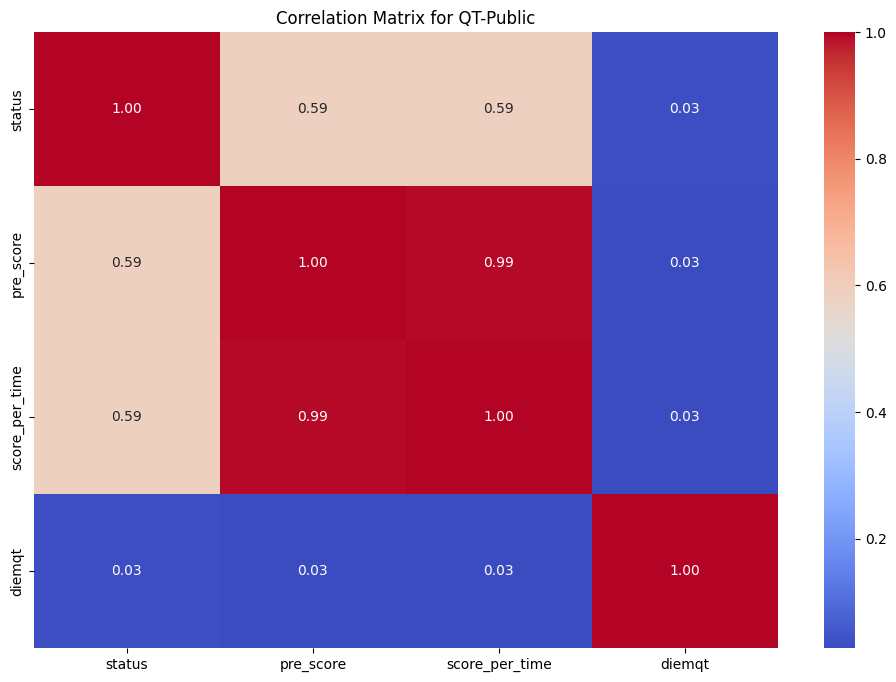

In [39]:
correlation_features = FEATURES_MAPPING["qt-public"] + ["diemqt"]
correlation_data = train_data[correlation_features]

correlation_data = correlation_data.apply(pd.to_numeric, errors='coerce').fillna(0)

corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for QT-Public")
plt.show()


In [40]:
train_and_predict("TH", FEATURES_MAPPING["th-public"], "th_results.csv")

C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)


R2-Score for TH: 0.022906482238842396


C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
C:\Users\windown\AppData\Local\Temp\ipykernel_11840\1569228194.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[target_col] = model.predict(X_test_final)


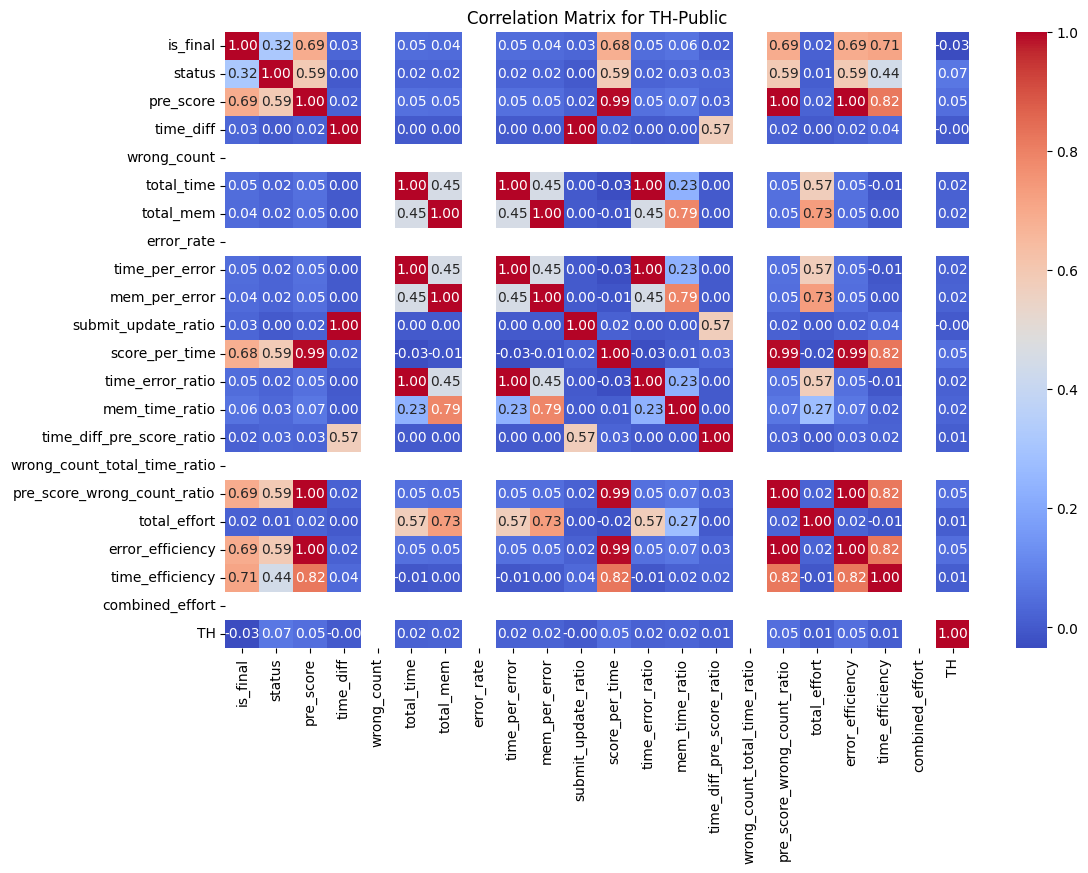

In [41]:
correlation_features = FEATURES_MAPPING["th-public"] + ["TH"]
correlation_data = train_data[correlation_features]

correlation_data = correlation_data.apply(pd.to_numeric, errors='coerce').fillna(0)

corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for TH-Public")
plt.show()

In [42]:
train_and_predict("CK", FEATURES_MAPPING["ck-public"], "ck_results.csv")

C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)


R2-Score for CK: 0.023697747718868678


C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
C:\Users\windown\AppData\Local\Temp\ipykernel_11840\1569228194.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[target_col] = model.predict(X_test_final)


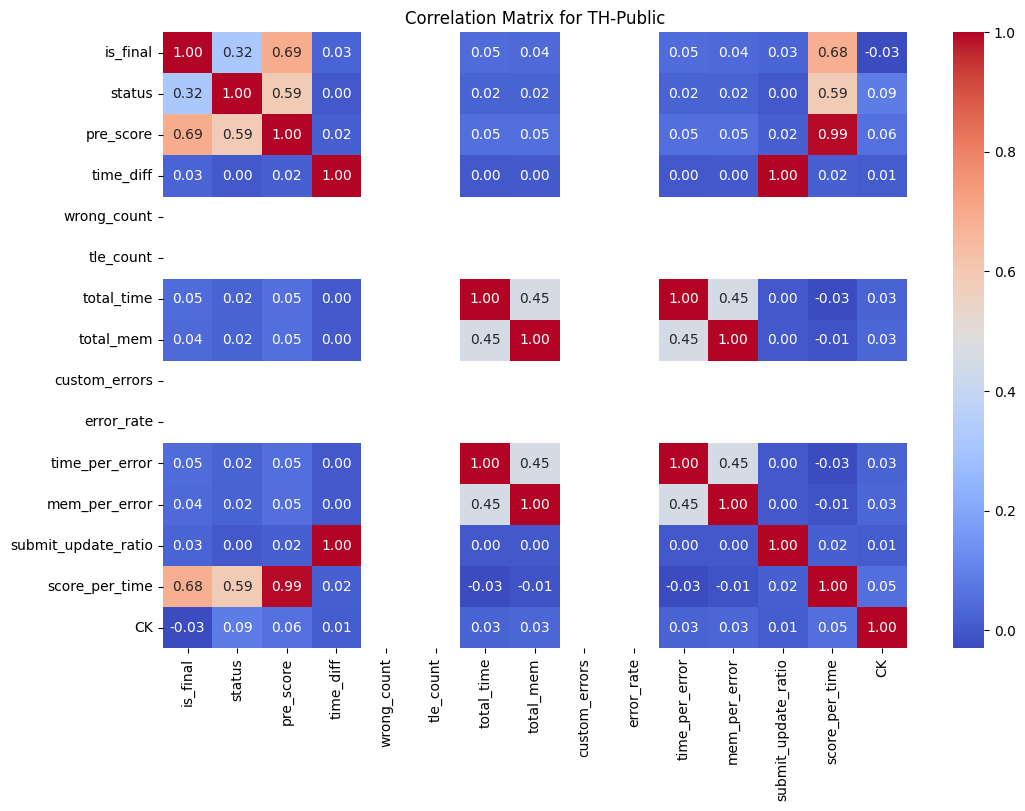

In [43]:
correlation_features = FEATURES_MAPPING["ck-public"] + ["CK"]
correlation_data = train_data[correlation_features]

correlation_data = correlation_data.apply(pd.to_numeric, errors='coerce').fillna(0)

corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for TH-Public")
plt.show()

In [44]:
train_and_predict("TBTL", FEATURES_MAPPING["tbtl-public"], "tbtl_results.csv")

C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)


R2-Score for TBTL: 0.012845201804739581


C:\Users\windown\AppData\Local\Temp\ipykernel_11840\2112065439.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
C:\Users\windown\AppData\Local\Temp\ipykernel_11840\1569228194.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[target_col] = model.predict(X_test_final)


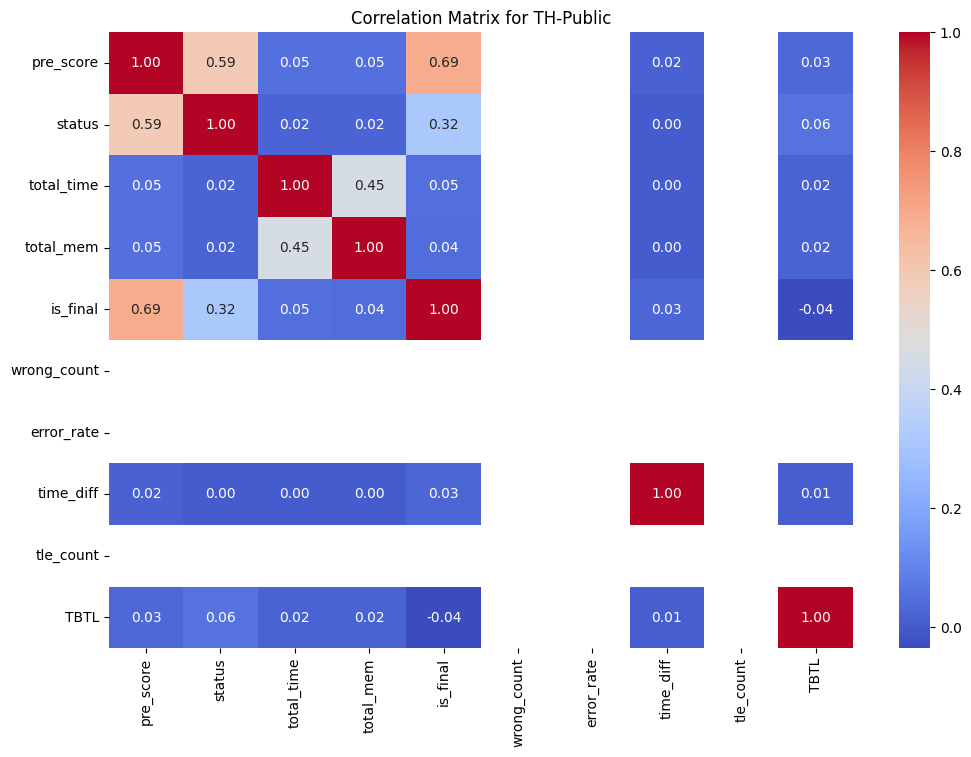

In [45]:
correlation_features = FEATURES_MAPPING["tbtl-public"] + ["TBTL"]
correlation_data = train_data[correlation_features]

correlation_data = correlation_data.apply(pd.to_numeric, errors='coerce').fillna(0)

corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for TH-Public")
plt.show()